# Apa yang Membuat Lagu Viral di Spotify?

---

## Latar Belakang

Jutaan lagu diunggah ke Spotify setiap tahunnya, namun hanya sebagian kecil yang berhasil meraih popularitas tinggi. Hal ini membuat musisi dan label musik kesulitan memahami faktor apa yang membuat sebuah lagu disukai banyak pendengar.

## Problem Statement

Menganalisis karakteristik audio dan genre yang membedakan lagu viral dari lagu biasa di platform Spotify, guna memberikan perspektif berbasis data bagi musisi dan label musik.

## Rumusan Masalah

1. Seperti apa distribusi popularitas lagu di Spotify — seberapa langka lagu yang benar-benar viral?
2. Genre apa yang paling konsisten menghasilkan lagu dengan popularitas tinggi?
3. Audio feature mana yang paling berkorelasi dengan popularitas?
4. Apakah lagu explicit lebih populer dibanding lagu non explicit?

## Load dan Cleaning Data
Langkah cleaning yang dilakukan:
- Menghapus 3 baris dengan nilai null
- Menghapus lagu dengan durasi 0ms karena tidak valid
- Menghapus lagu dengan popularity 0 karena kemungkinan belum pernah diputar
- Menghapus duplikat
- Menyeleksi 11 kolom yang relevan untuk analisis

Dataset final: 97.149 lagu siap dianalisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv(r"C:\temp\spotify.csv",index_col=0)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.68,0.46,1,-6.75,0,0.14,0.03,0.00,0.36,0.71,87.92,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.17,1,-17.23,1,0.08,0.92,0.00,0.10,0.27,77.49,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.44,0.36,0,-9.73,1,0.06,0.21,0.00,0.12,0.12,76.33,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.27,0.06,0,-18.52,1,0.04,0.91,0.00,0.13,0.14,181.74,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.62,0.44,2,-9.68,1,0.05,0.47,0.00,0.08,0.17,119.95,4,acoustic


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [3]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,35.00,212906.00,0.58,0.69,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,50.00,261506.00,0.69,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,0.99,243.37,5.00


In [4]:
# Hapus baris dengan nilai null
df = df.dropna()

# Hapus lagu dengan durasi 0 (data tidak valid)
df = df[df['duration_ms'] > 0]

# Hanya menggunakan data lagu yang aktif
df = df[df['popularity'] > 0]

# Hapus duplikat
df = df.drop_duplicates()

# Seleksi kolom yang relevan untuk analisis
kolom_penting = ['track_name', 'artists', 'track_genre', 'popularity', 
                 'danceability', 'energy', 'valence', 'tempo', 
                 'acousticness', 'loudness', 'explicit']
df = df[kolom_penting]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97706 entries, 0 to 113999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_name    97706 non-null  object 
 1   artists       97706 non-null  object 
 2   track_genre   97706 non-null  object 
 3   popularity    97706 non-null  int64  
 4   danceability  97706 non-null  float64
 5   energy        97706 non-null  float64
 6   valence       97706 non-null  float64
 7   tempo         97706 non-null  float64
 8   acousticness  97706 non-null  float64
 9   loudness      97706 non-null  float64
 10  explicit      97706 non-null  bool   
dtypes: bool(1), float64(6), int64(1), object(3)
memory usage: 8.3+ MB


## Analisis dan Perhitungan

### 1. Seperti apa distribusi popularitas lagu di Spotify?

In [5]:
print(df['popularity'].describe())

count   97706.00
mean       38.73
std        19.18
min         1.00
25%        23.00
50%        39.00
75%        53.00
max       100.00
Name: popularity, dtype: float64


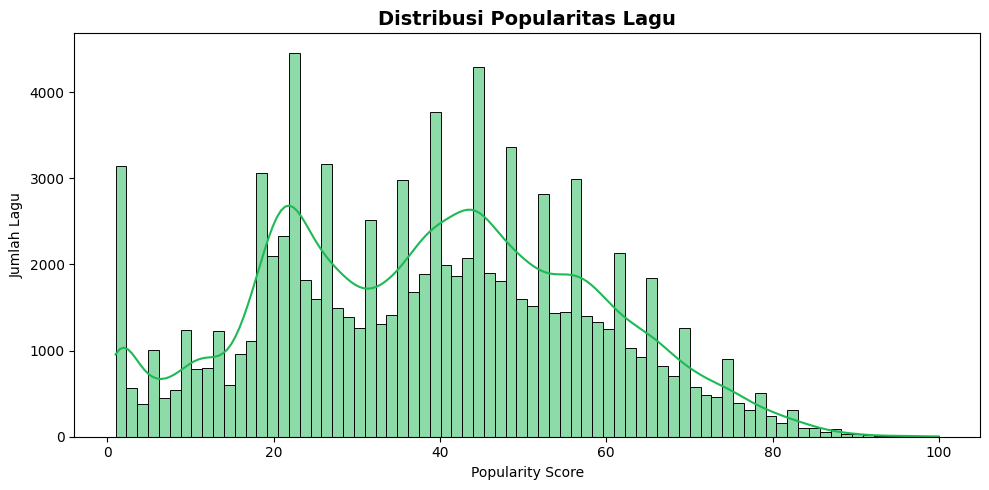

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(df['popularity'], color='#1DB954', kde=True)
plt.title('Distribusi Popularitas Lagu', fontsize=14, fontweight='bold')
plt.xlabel('Popularity Score')
plt.ylabel('Jumlah Lagu')

plt.tight_layout()
plt.show()


### Insight
Mayoritas lagu yang aktif didengar memiliki popularitas di rentang 20–60. 
Semakin tinggi popularitasnya, semakin sedikit lagunya. 
Ini menunjukkan bahwa menjadi viral di Spotify adalah pencapaian yang sangat langka.

### 2. Genre apa yang paling konsisten menghasilkan lagu dengan popularitas tinggi?

In [7]:
mean_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).reset_index()

print(mean_genre.head(10))

  track_genre  popularity
0    pop-film       59.40
1       k-pop       59.22
2         pop       58.37
3     electro       58.00
4       house       57.31
5       chill       55.89
6         edm       55.04
7       metal       54.97
8   indie-pop       54.87
9       indie       54.48


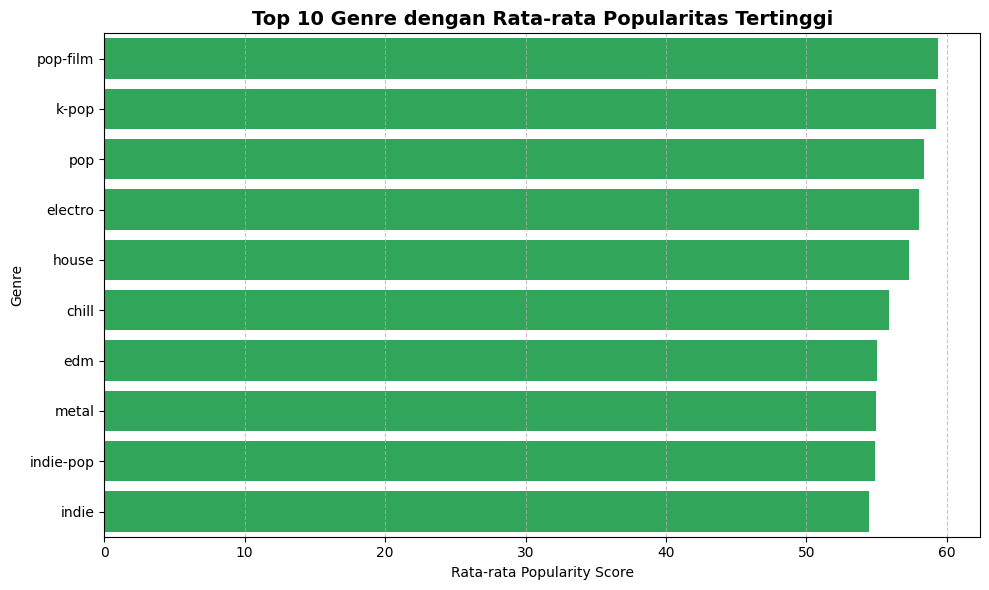

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mean_genre.head(10), x='popularity', y='track_genre', color='#1DB954')
plt.title('Top 10 Genre dengan Rata-rata Popularitas Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Popularity Score')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight: 
Genre pop, pop-film, dan k-pop menempati posisi teratas dengan rata-rata 
popularitas tertinggi. Namun selisih antar genre sangat kecil — dari pop 
hingga indie hanya berbeda sekitar 6 poin. Ini menunjukkan bahwa genre 
bukan faktor penentu utama popularitas sebuah lagu di Spotify.

### 3. Audio feature mana yang paling berkorelasi dengan popularitas?

In [9]:
audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'loudness']

correlations = df[audio_features].corrwith(df['popularity']).sort_values(ascending=False)
print(correlations)

loudness        0.07
danceability    0.06
acousticness   -0.01
valence        -0.01
tempo          -0.02
energy         -0.04
dtype: float64


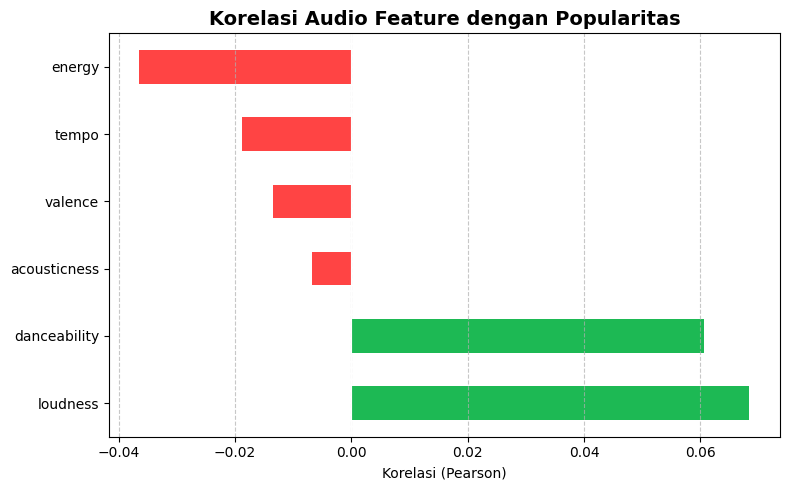

In [10]:
plt.figure(figsize=(8, 5))
correlations.plot(kind='barh', color=['#1DB954' if x > 0 else '#ff4444' for x in correlations])
plt.title('Korelasi Audio Feature dengan Popularitas', fontsize=14, fontweight='bold')
plt.xlabel('Korelasi (Pearson)')
plt.axvline(x=0, color='white', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight
Tidak ada audio feature yang memiliki korelasi kuat dengan popularitas. 
Loudness dan danceability menunjukkan korelasi positif tertinggi namun 
nilainya sangat kecil. Ini menunjukkan bahwa karakteristik teknis audio 
sebuah lagu bukan faktor penentu utama popularitasnya di Spotify.

### 4. Apakah lagu explicit lebih populer dibanding lagu non explicit?

In [11]:
explicit_mean = df.groupby('explicit')['popularity'].mean()
print(explicit_mean)

explicit
False   38.41
True    42.14
Name: popularity, dtype: float64


C:\Users\rinal\AppData\Local\Temp\ipykernel_2656\75762369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=explicit_mean.index.map({True: 'Explicit', False: 'Non-Explicit'}),


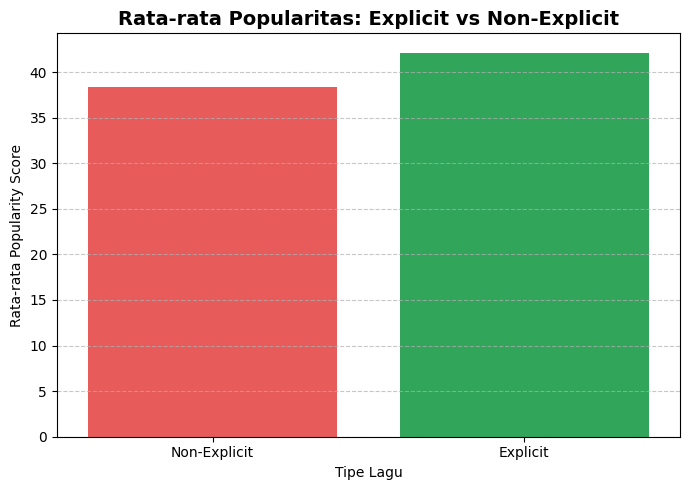

In [12]:
plt.figure(figsize=(7, 5))
sns.barplot(x=explicit_mean.index.map({True: 'Explicit', False: 'Non-Explicit'}), 
            y=explicit_mean.values, 
            palette=['#ff4444', '#1DB954'])
plt.title('Rata-rata Popularitas: Explicit vs Non-Explicit', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Lagu')
plt.ylabel('Rata-rata Popularity Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight:
Lagu explicit memiliki rata-rata popularitas yang sedikit lebih tinggi 
dibanding lagu non-explicit. Namun perbedaannya kecil, sehingga konten 
explicit bukan faktor penentu utama popularitas sebuah lagu.

## Kesimpulan

Analisis terhadap 97.149 lagu di Spotify menunjukkan bahwa tidak ada satu faktor tunggal yang secara dominan menentukan popularitas sebuah lagu.

Dari sisi genre, pop, pop-film, dan k-pop menempati posisi teratas namun selisih antar genre sangat kecil — menunjukkan bahwa genre bukan penentu utama popularitas.

Dari sisi audio features, tidak ada yang berkorelasi kuat dengan popularitas. Loudness dan danceability memiliki korelasi positif tertinggi namun nilainya sangat kecil.

Dari sisi konten, lagu explicit sedikit lebih populer dibanding non-explicit, namun perbedaannya tidak signifikan.

Secara keseluruhan, popularitas di Spotify kemungkinan besar lebih dipengaruhi oleh faktor di luar data yang tersedia. Hal ini mengindikasikan bahwa viral di Spotify bukan soal bagaimana sebuah lagu terdengar secara teknis, melainkan lebih kepada siapa yang membawakannya dan bagaimana lagu tersebut dipromosikan.

Catatan: Dataset ini tidak memiliki informasi waktu rilis, sehingga analisis tren popularitas dari waktu ke waktu tidak dapat dilakukan.

## Rekomendasi

Berdasarkan hasil analisis, tidak ada formula audio yang bisa menjamin sebuah lagu menjadi viral di Spotify.

Namun ada beberapa hal yang bisa diperhatikan:

- Dari semua audio feature, Loudness dan danceability adalah satu-satunya audio feature yang berkorelasi positif dengan popularitas, namun nilainya sangat kecil sehingga tidak bisa diandalkan sebagai strategi utama.

- Genre bukan faktor penentu yang bisa diandalkan — selisih popularitas antar genre sangat kecil sehingga memilih genre tertentu tidak menjamin lagu lebih populer.

- Faktor di luar data seperti kualitas lagu, promosi, dan nama artis kemungkinan lebih berpengaruh dari karakteristik audio lagu itu sendiri.

In [13]:
df.to_csv('spotify_clean.csv', index=False)